# Notebook 04 — Protein Feature Extraction

**PharmaLens: An Explainable AI Framework for Drug–Target Interaction Prediction**

---

## Objective

This notebook extracts numerical representations from protein amino acid sequences.

We generate:
1. **Amino Acid Composition (AAC)** — Frequency of each of the 20 standard amino acids (20D)
2. **Dipeptide Composition (DPC)** — Frequency of consecutive amino acid pairs (400D)
3. **Conjoint Triad (CT)** — Grouped amino acid triad patterns (343D)
4. **Sequence Encoding** — Integer encoding for DeepDTA-style CNN models

**Why these features?** Protein structure determines function, but computing full 3D structure is expensive. Sequence-based features capture statistical patterns in the amino acid sequence that correlate with physicochemical properties and structural motifs.

## Setup

In [1]:
import os, sys, warnings, pickle
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.utils.config import PROCESSED_DATA_DIR, FIGURES_DIR, ensure_dirs, set_seed, set_plot_style
from src.features.protein_features import (
    amino_acid_composition, dipeptide_composition, conjoint_triad,
    ctd_composition, encode_sequence, encode_sequences_batch,
    get_protein_feature_vector, get_protein_feature_names,
    AMINO_ACIDS,
)

set_seed(42)
COLORS = set_plot_style()
ensure_dirs()
print("Setup complete ✓")

Setup complete ✓


## 1. Load Cleaned Data

In [2]:
df = pd.read_csv(PROCESSED_DATA_DIR / 'kiba_clean.csv')
unique_targets = df.drop_duplicates('target_id')[['target_id', 'sequence']].reset_index(drop=True)
print(f"Unique protein targets: {len(unique_targets)}")

# Sequence length stats
unique_targets['seq_len'] = unique_targets['sequence'].str.len()
print(f"Sequence lengths: min={unique_targets['seq_len'].min()}, max={unique_targets['seq_len'].max()}, "
      f"mean={unique_targets['seq_len'].mean():.0f}, median={unique_targets['seq_len'].median():.0f}")
unique_targets.head()

Unique protein targets: 229
Sequence lengths: min=215, max=4128, mean=729, median=620


,target_id,sequence,seq_len
0,O00141,MTVKTEAAKGTLTYSRMRGMVAILIAFMKQRRMGLNDFIQKIANNS...,431
1,O14920,MSWSPSLTTQTCGAWEMKERLGTGGFGNVIRWHNQETGEQIAIKQC...,756
2,O15111,MERPPGLRPGAGGPWEMRERLGTGGFGNVCLYQHRELDLKIAIKSC...,745
3,P00533,MRPSGTAGAALLALLAALCPASRALEEKKVCQGTSNKLTQLGTFED...,1210
4,P04626,MELAALCRWGLLLALLPPGAASTQVCTGTDMKLRLPASPETHLDML...,1255


## 2. Amino Acid Composition (AAC)

AAC is the simplest protein feature — a 20-dimensional vector where each element is the fraction of the corresponding amino acid in the sequence.

AAC matrix shape: (229, 20)


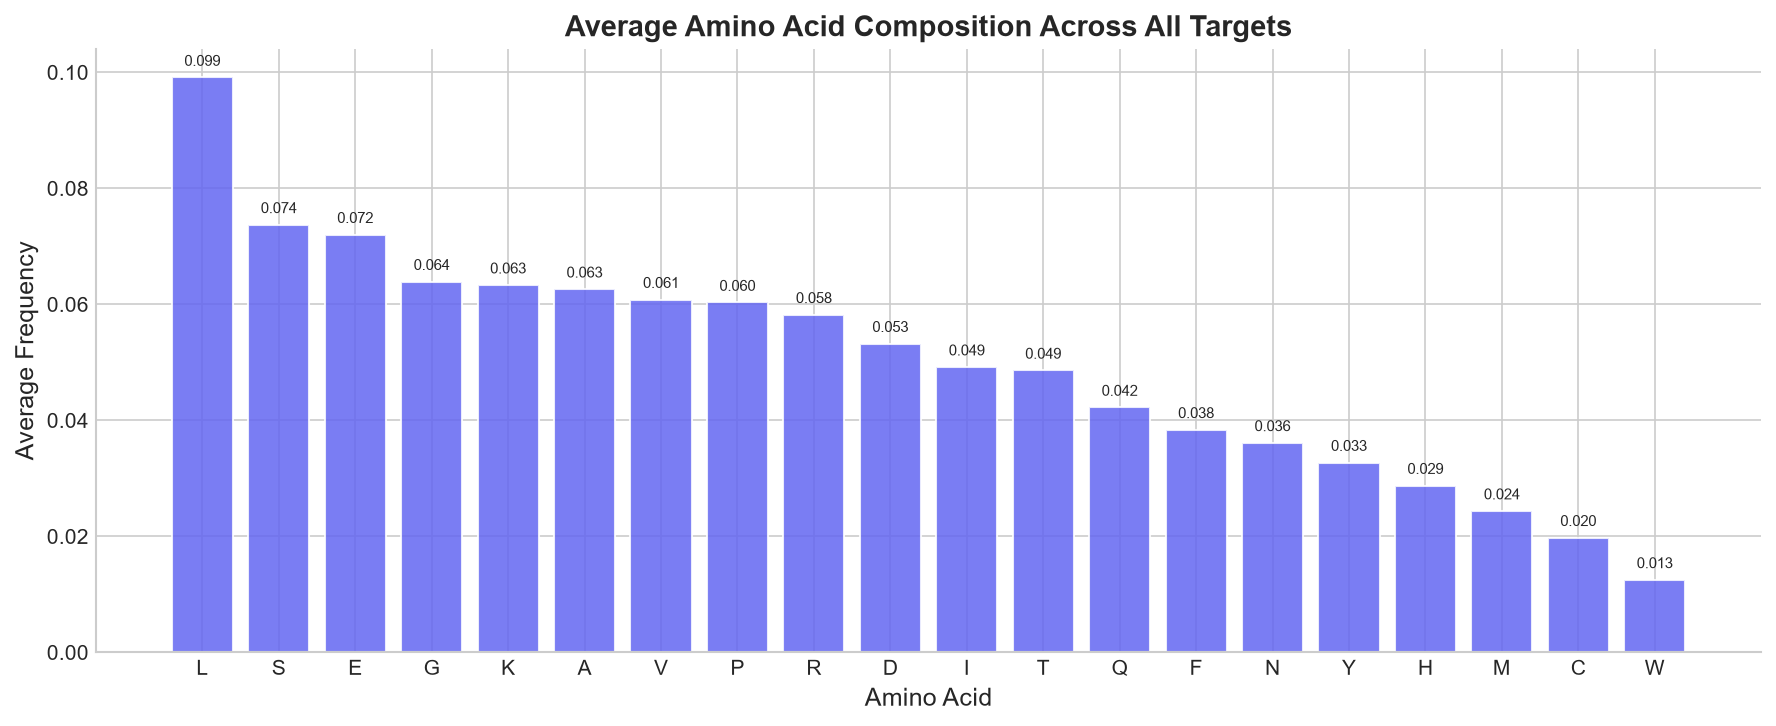

In [3]:
# Compute AAC for all targets
aac_list = [amino_acid_composition(seq) for seq in unique_targets['sequence']]
aac_matrix = np.array(aac_list)
print(f"AAC matrix shape: {aac_matrix.shape}")

# Average amino acid composition across all targets
aac_df = pd.DataFrame(aac_matrix, columns=AMINO_ACIDS)
avg_aac = aac_df.mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(avg_aac.index, avg_aac.values, color=COLORS['primary'], alpha=0.85, edgecolor='white')
ax.set_xlabel('Amino Acid')
ax.set_ylabel('Average Frequency')
ax.set_title('Average Amino Acid Composition Across All Targets', fontweight='bold')
for bar, val in zip(bars, avg_aac.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', fontsize=7, rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'protein_aac_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Dipeptide Composition (DPC)

DPC captures local sequence patterns by counting consecutive amino acid pairs. It produces a 400-dimensional vector (20×20 possible pairs) and captures more structural information than AAC alone.

DPC matrix shape: (229, 400)
Non-zero features per protein: mean=275


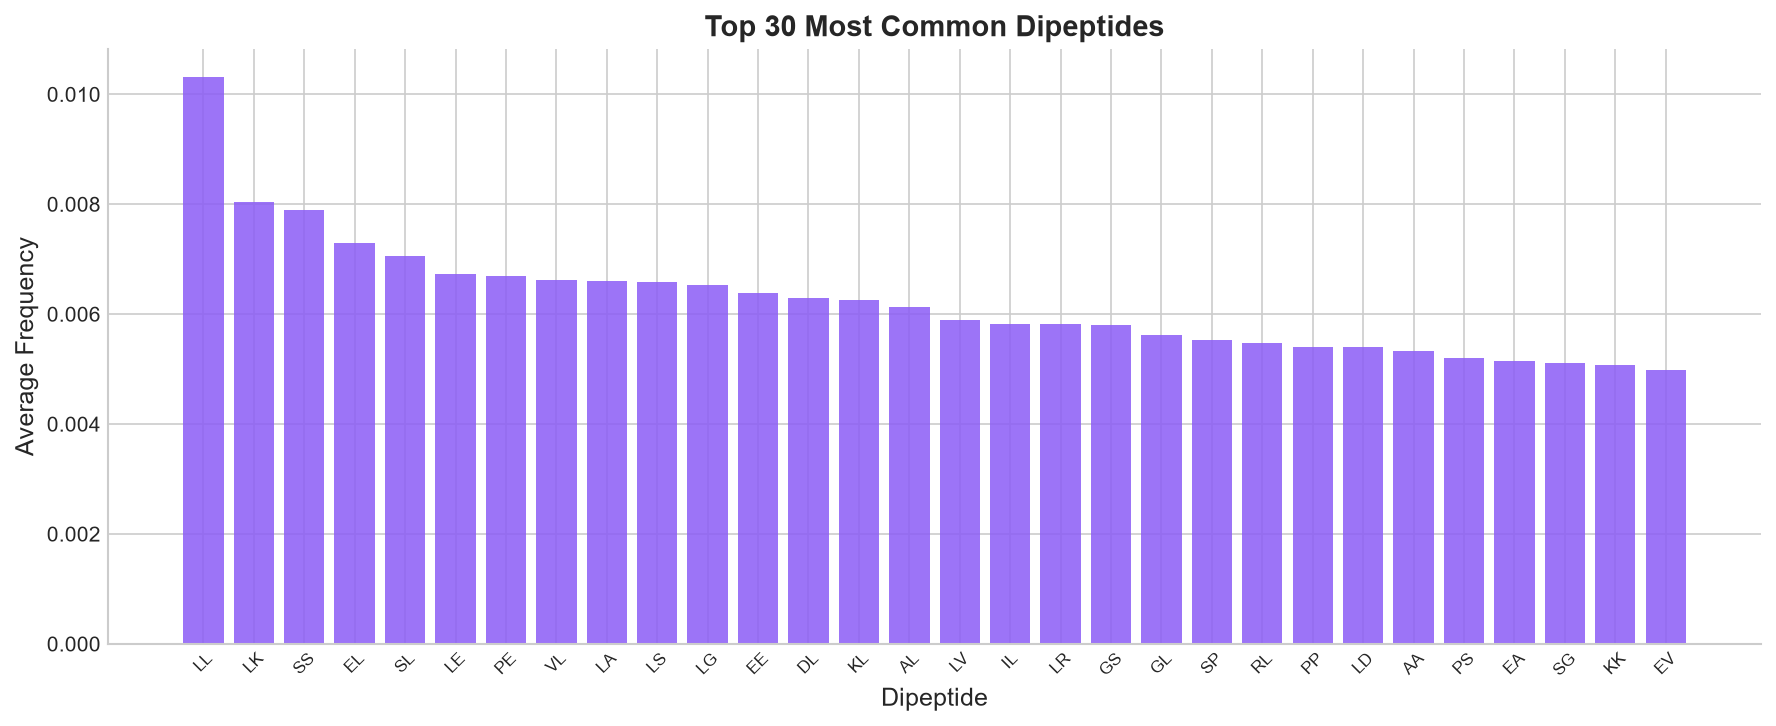

In [4]:
# Compute DPC for all targets
dpc_list = [dipeptide_composition(seq) for seq in unique_targets['sequence']]
dpc_matrix = np.array(dpc_list)
print(f"DPC matrix shape: {dpc_matrix.shape}")
print(f"Non-zero features per protein: mean={np.mean(np.sum(dpc_matrix > 0, axis=1)):.0f}")

# Top dipeptides
dpc_names = [f'{a1}{a2}' for a1 in AMINO_ACIDS for a2 in AMINO_ACIDS]
avg_dpc = pd.Series(dpc_matrix.mean(axis=0), index=dpc_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
top_n = 30
ax.bar(range(top_n), avg_dpc.values[:top_n], color=COLORS['secondary'], alpha=0.85)
ax.set_xticks(range(top_n))
ax.set_xticklabels(avg_dpc.index[:top_n], rotation=45, fontsize=8)
ax.set_xlabel('Dipeptide')
ax.set_ylabel('Average Frequency')
ax.set_title(f'Top {top_n} Most Common Dipeptides', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'protein_dpc_top30.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Sequence Encoding (for DeepDTA)

Similar to SMILES encoding, protein sequences are converted to fixed-length integer vectors for 1D CNN processing.

In [5]:
# Encode all protein sequences
MAX_SEQ_LEN = 1000
encoded_sequences = encode_sequences_batch(unique_targets['sequence'].tolist(), max_length=MAX_SEQ_LEN)
print(f"Encoded sequence matrix shape: {encoded_sequences.shape}")

# Check truncation
actual_lengths = unique_targets['seq_len'].values
n_truncated = np.sum(actual_lengths > MAX_SEQ_LEN)
print(f"Sequences truncated (>{MAX_SEQ_LEN} AA): {n_truncated} / {len(actual_lengths)}")
if n_truncated > 0:
    print(f"  Longest sequence: {actual_lengths.max()} AA")

Encoded sequence matrix shape: (229, 1000)
Sequences truncated (>1000 AA): 44 / 229
  Longest sequence: 4128 AA


## 5. Combined Protein Feature Vector

In [6]:
# Compute combined feature vectors (AAC + DPC) for RF/XGBoost
from tqdm import tqdm

target_feature_dict = {}
for _, row in tqdm(unique_targets.iterrows(), total=len(unique_targets), desc='Computing protein features'):
    fv = get_protein_feature_vector(row['sequence'], include_aac=True, include_dpc=True)
    target_feature_dict[row['target_id']] = fv

sample_fv = next(iter(target_feature_dict.values()))
feature_names = get_protein_feature_names(include_aac=True, include_dpc=True)
print(f"\nFeature vector size: {len(sample_fv)} (20 AAC + 400 DPC)")
print(f"Computed features for {len(target_feature_dict)} targets")

Computing protein features: 100%|██████████| 229/229 [00:00<00:00, 3620.74it/s]


Feature vector size: 420 (20 AAC + 400 DPC)
Computed features for 229 targets


## 6. Save Features

In [7]:
# Save protein feature dictionary
with open(PROCESSED_DATA_DIR / 'protein_features.pkl', 'wb') as f:
    pickle.dump(target_feature_dict, f)
print(f"Protein features saved: {PROCESSED_DATA_DIR / 'protein_features.pkl'}")

# Save encoded sequences
np.save(PROCESSED_DATA_DIR / 'protein_sequences_encoded.npy', encoded_sequences)
print(f"Encoded sequences saved: {PROCESSED_DATA_DIR / 'protein_sequences_encoded.npy'}")

# Save target ID mapping
target_id_map = dict(zip(range(len(unique_targets)), unique_targets['target_id']))
with open(PROCESSED_DATA_DIR / 'target_id_map.pkl', 'wb') as f:
    pickle.dump(target_id_map, f)

# Feature summary
summary = {
    'n_targets': len(target_feature_dict),
    'aac_dim': 20,
    'dpc_dim': 400,
    'combined_dim': len(sample_fv),
    'encoded_max_len': MAX_SEQ_LEN,
    'n_truncated': int(n_truncated),
}
print(f"\nFeature Summary: {summary}")

Protein features saved: C:\Users\ASUS\Documents\projects\Pharmalens\data\processed\protein_features.pkl
Encoded sequences saved: C:\Users\ASUS\Documents\projects\Pharmalens\data\processed\protein_sequences_encoded.npy

Feature Summary: {'n_targets': 229, 'aac_dim': 20, 'dpc_dim': 400, 'combined_dim': 420, 'encoded_max_len': 1000, 'n_truncated': 44}


## Observations

1. **Amino acid composition** reveals the typical distribution of amino acids in kinase-related proteins. Leucine (L), Glutamic acid (E), and Alanine (A) are often the most abundant.

2. **Dipeptide composition** captures local sequence patterns that relate to secondary structure elements.

3. **Sequence lengths** vary substantially. Truncation to 1000 residues for DeepDTA may discard some C-terminal information for longer proteins.

## Conclusion

Protein features are computed and saved:
- AAC + DPC combined vectors (420D) for RF/XGBoost
- Integer-encoded sequences (1000D) for DeepDTA

**Next:** [Notebook 05 — Baseline Models](./05_baseline_models.ipynb)